In [1]:
import matplotlib.pyplot as plt
from Bio import SeqIO
import numpy as np
%matplotlib inline

def analyze_sequence_lengths(fasta_file, xlim=None, ylim=None):
    sequences = list(SeqIO.parse(fasta_file, "fasta"))

    # 计算有效长度（移除尾部星号）
    def get_effective_length(seq):
        return len(seq.rstrip('*'))

    lengths = [get_effective_length(str(seq.seq)) for seq in sequences]

    # 计算长度分布
    unique_lengths, counts = np.unique(lengths, return_counts=True)


    # Plot length distribution histogram
    plt.figure(figsize=(12, 6))
    plt.bar(unique_lengths, counts)
    plt.xlabel('Sequence Length')
    plt.ylabel('Count')
    if ylim:
        plt.ylim(0, ylim)
    if xlim:
        plt.xlim(0, xlim)
    plt.title('5\'UTR Sequence Length Distribution')
    plt.show()

    # Print basic statistical information
    print(f"Total number of sequences: {len(sequences)}")
    print(f"Shortest sequence length: {min(lengths)}")
    print(f"Longest sequence length: {max(lengths)}")
    print(f"Average sequence length: {np.mean(lengths):.2f}")
    print(f"Median sequence length: {np.median(lengths):.2f}")

    return lengths

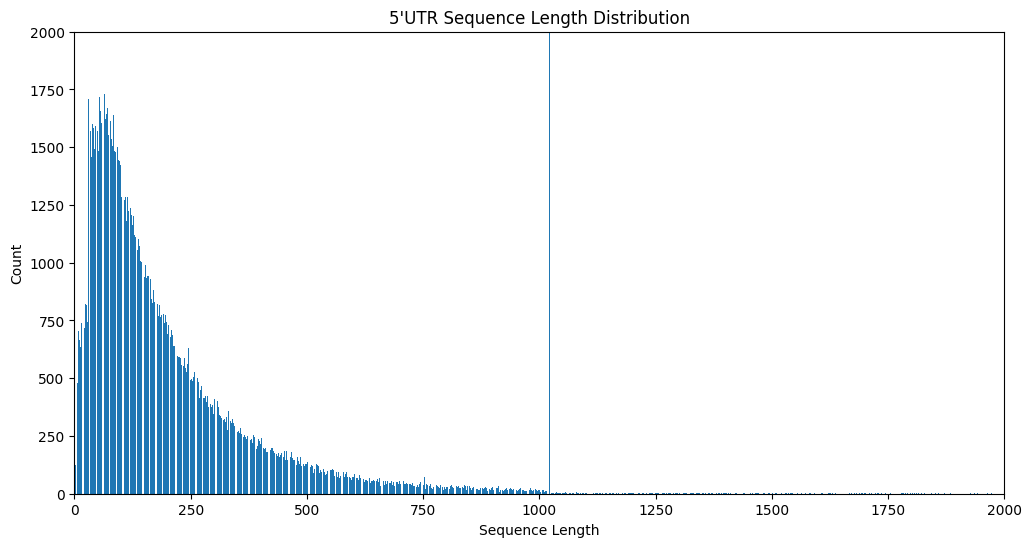

Total number of sequences: 360322
Shortest sequence length: 1
Longest sequence length: 6566
Average sequence length: 209.03
Median sequence length: 143.00


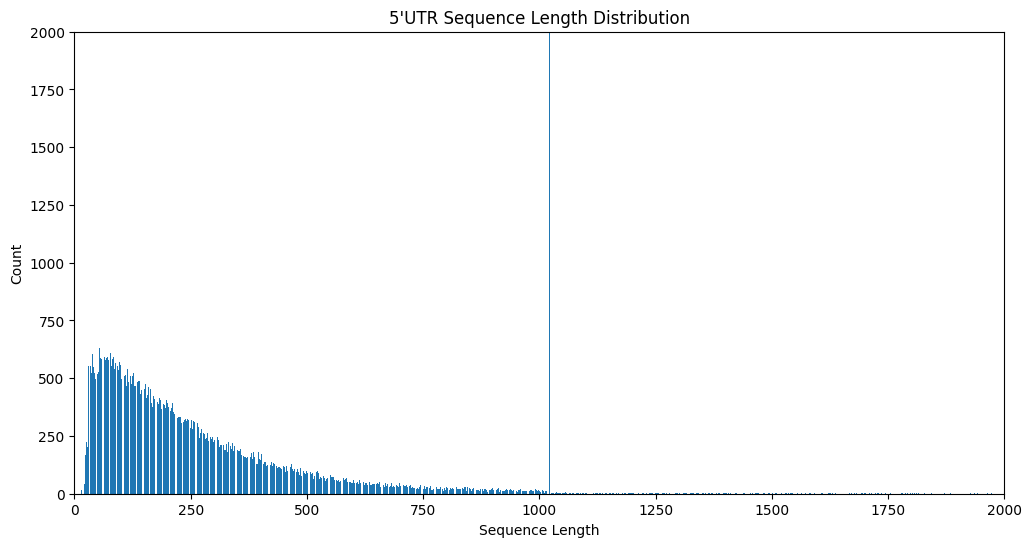

Total number of sequences: 173630
Shortest sequence length: 14
Longest sequence length: 6566
Average sequence length: 269.01
Median sequence length: 199.00


[211,
 573,
 59,
 78,
 77,
 123,
 84,
 229,
 70,
 77,
 378,
 1218,
 70,
 186,
 58,
 47,
 211,
 49,
 49,
 381,
 55,
 143,
 845,
 17,
 119,
 111,
 558,
 191,
 133,
 40,
 123,
 93,
 217,
 22,
 70,
 543,
 120,
 89,
 39,
 200,
 26,
 276,
 189,
 44,
 99,
 120,
 211,
 123,
 297,
 537,
 693,
 70,
 188,
 137,
 38,
 35,
 171,
 191,
 99,
 933,
 64,
 69,
 89,
 42,
 193,
 59,
 92,
 189,
 157,
 102,
 458,
 42,
 46,
 31,
 44,
 190,
 34,
 1101,
 87,
 110,
 529,
 73,
 141,
 114,
 97,
 60,
 227,
 360,
 125,
 20,
 238,
 15,
 609,
 73,
 45,
 274,
 308,
 192,
 17,
 68,
 302,
 74,
 96,
 261,
 81,
 748,
 194,
 48,
 59,
 39,
 69,
 60,
 142,
 41,
 263,
 309,
 173,
 506,
 75,
 260,
 573,
 45,
 89,
 139,
 168,
 143,
 77,
 61,
 85,
 86,
 164,
 354,
 70,
 186,
 73,
 56,
 112,
 340,
 75,
 31,
 41,
 668,
 45,
 137,
 2147,
 19,
 375,
 92,
 299,
 45,
 63,
 56,
 51,
 69,
 92,
 344,
 19,
 712,
 243,
 80,
 195,
 167,
 55,
 71,
 87,
 680,
 1904,
 156,
 19,
 795,
 154,
 46,
 214,
 115,
 79,
 76,
 406,
 106,
 24,
 49,
 68,


In [2]:
analyze_sequence_lengths("../data/5utr_full.fasta", 2000, 2000)
analyze_sequence_lengths("../data/5utr_95.fasta", 2000, 2000)

## 64-128

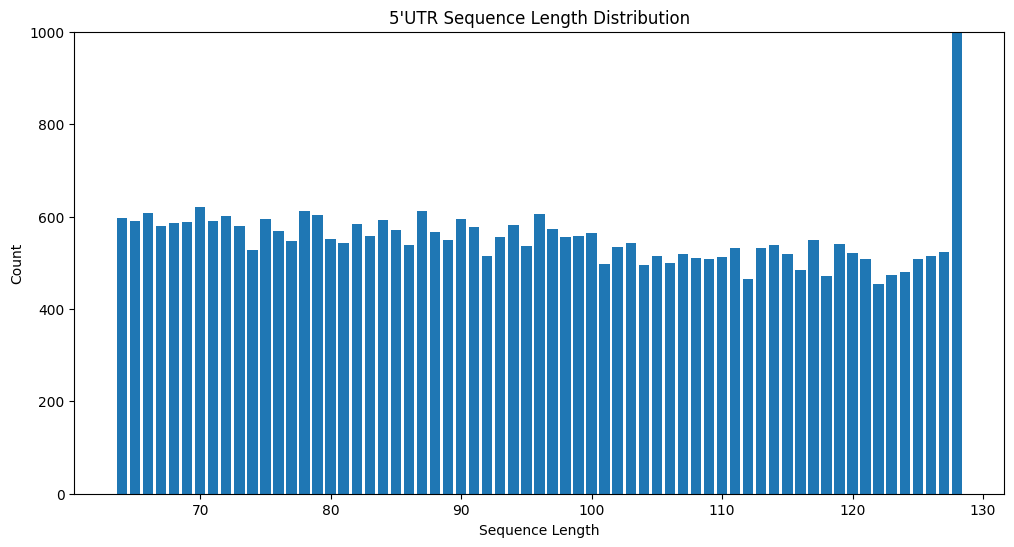

Total number of sequences: 152810
Shortest sequence length: 64
Longest sequence length: 128
Average sequence length: 120.30
Median sequence length: 128.00
长度大于128的80%（即102.4）的序列比例：85.40%


In [7]:
# Read the FASTA file
fasta_file = "../data/5utr_95_64to128.fasta"
lengths = analyze_sequence_lengths(fasta_file, None, 10000)

threshold = 0.8 * 128
proportion = len([l for l in lengths if l > threshold]) / len(lengths)
print(f"长度大于128的80%（即{threshold}）的序列比例：{proportion:.2%}")


## 64-256

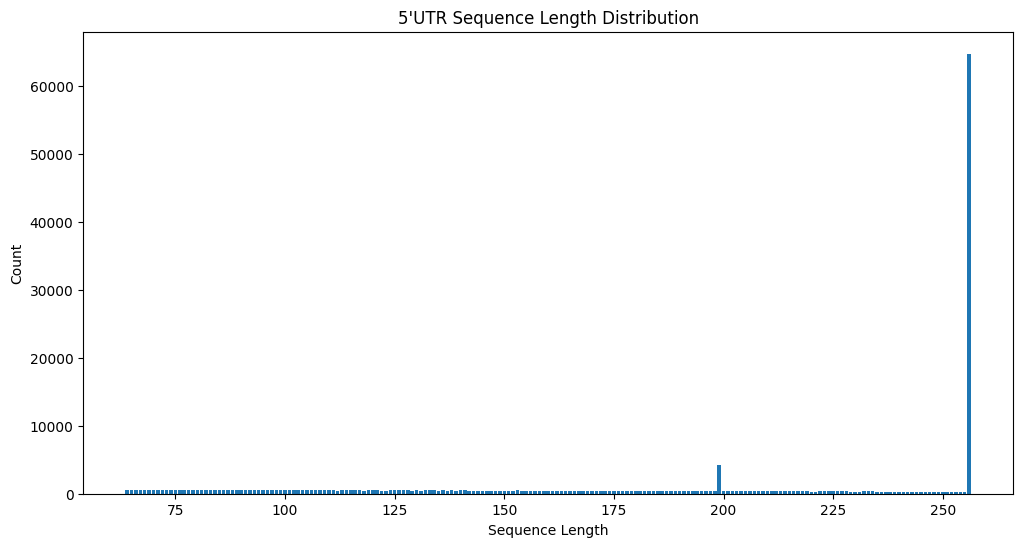

Total number of sequences: 152810
Shortest sequence length: 64
Longest sequence length: 256
Average sequence length: 195.04
Median sequence length: 219.00
长度大于256的80%（即204.8）的序列比例：53.26%


In [4]:
fasta_file = "../data/5utr_95_64to256.fasta"
lengths = analyze_sequence_lengths(fasta_file, None, None)

threshold = 0.8 * 256
proportion = len([l for l in lengths if l > threshold]) / len(lengths)
print(f"长度大于256的80%（即{threshold}）的序列比例：{proportion:.2%}")

## 64-512

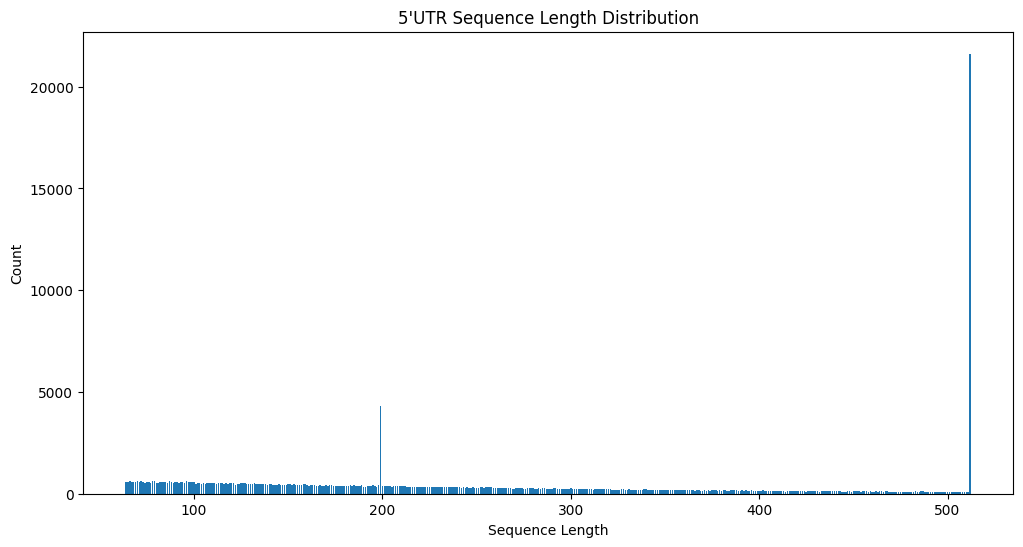

Total number of sequences: 152810
Shortest sequence length: 64
Longest sequence length: 512
Average sequence length: 259.91
Median sequence length: 219.00
长度大于512的80%（即409.6）的序列比例：21.42%


In [5]:
fasta_file = "../data/5utr_95_64to512.fasta"
lengths = analyze_sequence_lengths(fasta_file, None, None)

threshold = 0.8 * 512
proportion = len([l for l in lengths if l > threshold]) / len(lengths)
print(f"长度大于512的80%（即{threshold}）的序列比例：{proportion:.2%}")


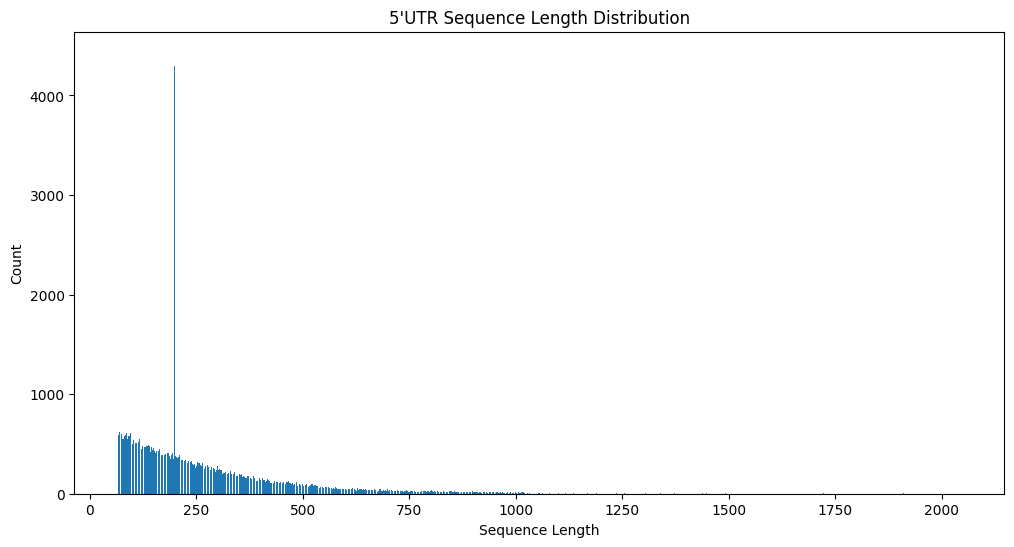

Total number of sequences: 152810
Shortest sequence length: 64
Longest sequence length: 2048
Average sequence length: 298.68
Median sequence length: 219.00


In [6]:
fasta_file = "../data/5utr_95_64to2048.fasta"
lengths = analyze_sequence_lengths(fasta_file, None, None)

In [7]:
from Bio import SeqIO

def check_sequence_overlap(homo_file, noHomo_file):
    # 读取homo序列
    homo_seqs = set()
    for record in SeqIO.parse(homo_file, "fasta"):
        homo_seqs.add(str(record.seq))
    
    print(f"从homo文件中读取了{len(homo_seqs)}条序列")
    
    # 检查noHomo序列是否在homo中出现
    overlap_count = 0
    total_count = 0
    for record in SeqIO.parse(noHomo_file, "fasta"):
        total_count += 1
        if str(record.seq) in homo_seqs:
            overlap_count += 1
            
    print(f"noHomo文件中共有{total_count}条序列")
    print(f"其中{overlap_count}条序列在homo文件中出现")
    print(f"重叠比例: {overlap_count/total_count:.2%}")

# 检查序列重叠情况
homo_file = "../data/5utr_homo_90_64to256.fasta"
noHomo_file = "../data/5utr_noHomo_90_64to256.fasta" 
check_sequence_overlap(homo_file, noHomo_file)


从homo文件中读取了44662条序列
noHomo文件中共有102574条序列
其中131条序列在homo文件中出现
重叠比例: 0.13%
